# **Project - Churn Analysis & Predictive Modeling**

**Author:** Abdallah Idris Benseghir  
**Date:** February 2026  
**Dataset 1:** `customer_churn_dataset-training-master.csv`   
**Dataset 2:** `customer_churn_dataset-testing-master.csv`

---


## **Setup & Data Loading**

In [1]:
# Import libraries
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [2]:
# Dataset Loading
data_path = "Data/Processed/Final_v_customer_churn_dataset.csv"

data = pd.read_csv(data_path)

In [3]:
# Basic Dataset Overview
print("Dataset Shape:", data.shape)


print("\nDataset Preview:")
display(data.head())

Dataset Shape: (505206, 16)

Dataset Preview:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Age_Group,EngagementScore,EngagementLevel,AvgSpend,LatePaymentFlag
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.0,17.0,1.0,19-40,9.0,Medium,23.897436,1
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.0,6.0,1.0,61-100,-9.0,Low,11.367347,0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.0,3.0,1.0,41-60,-2.0,Low,13.214286,1
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.0,29.0,1.0,41-60,14.0,High,10.421053,0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.0,20.0,1.0,19-40,15.0,High,19.281250,0


## **Modeling Phase 1: Establishing a Baseline**

* ### **Data Preparation for Modeling**

In [4]:
# Feature-Target Selection 
target = data['Churn']
features = data.drop(columns=['EngagementLevel','Age_Group','Churn'])

display(target.head())
display(features.head())

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: Churn, dtype: float64

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,EngagementScore,AvgSpend,LatePaymentFlag
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.0,17.0,9.0,23.897436,1
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.0,6.0,-9.0,11.367347,0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.0,3.0,-2.0,13.214286,1
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.0,29.0,14.0,10.421053,0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.0,20.0,15.0,19.281250,0


In [5]:
# Train-Test Split
feature_train, feature_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=0
)

# Reindexing for Train set
x_train = feature_train.reset_index(drop=True)
y_train = target_train.reset_index(drop=True)

print('Train sets:')
display(x_train.head())
print()
display(y_train.head())
print()

# Reindexing for Test set
x_test = feature_test.reset_index(drop=True)
y_test = target_test.reset_index(drop=True)

print('Test sets:')
display(x_test.head())
print()
display(y_test.head())


Train sets:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,EngagementScore,AvgSpend,LatePaymentFlag
0,41.0,1,28.0,2.0,2.0,6.0,2,1,502.45,2.0,0.0,17.944643,0
1,43.0,0,46.0,17.0,3.0,0.0,2,1,517.58,11.0,14.0,11.251739,0
2,32.0,1,27.0,10.0,2.0,2.0,0,1,798.05,16.0,8.0,29.557407,0
3,45.0,1,48.0,9.0,2.0,17.0,2,2,959.57,23.0,7.0,19.991042,1
4,30.0,1,5.0,9.0,2.0,17.0,2,1,783.65,12.0,7.0,156.730000,1


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Churn, dtype: float64


Test sets:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,EngagementScore,AvgSpend,LatePaymentFlag
0,41.0,1,60.0,3.0,8.0,27.0,1,0,409.00,18.0,-5.0,6.816667,1
1,25.0,1,6.0,26.0,1.0,7.0,2,2,780.31,9.0,25.0,130.051667,0
2,20.0,0,28.0,24.0,5.0,4.0,0,2,230.47,10.0,19.0,8.231071,0
3,50.0,0,36.0,3.0,0.0,10.0,1,2,825.37,6.0,3.0,22.926944,0
4,43.0,1,53.0,4.0,2.0,20.0,0,1,918.85,7.0,2.0,17.336792,1


0    1.0
1    0.0
2    1.0
3    0.0
4    0.0
Name: Churn, dtype: float64

* ### **Base Model: Logistic Regression**

In [16]:
# Model Initilizing 
model = LogisticRegression(max_iter=2000)

# Model Training / Fitting
model.fit(x_train, y_train)

# Predict on the test set
y_pred = model.predict(x_test)

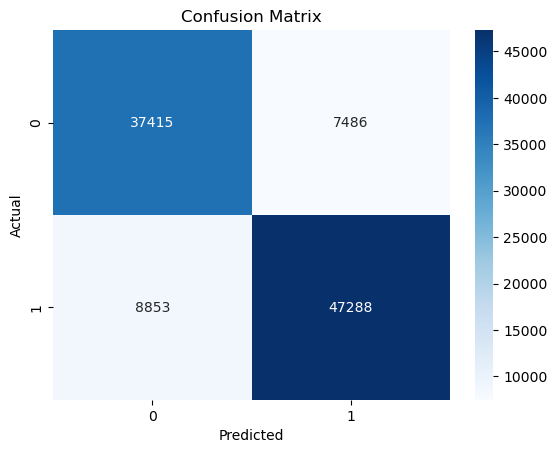

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Confusion Matrix Plot
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [18]:
# Evaluation Metric 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy,2)*100)
print("Precision:", round(precision,3)*100)
print("Recall   :", round(recall,3)*100)
print("F1-Score :", round(f1,3)*100)
print(classification_report(y_test, y_pred))

Accuracy : 84.0
Precision: 86.3
Recall   : 84.2
F1-Score : 85.3
              precision    recall  f1-score   support

         0.0       0.81      0.83      0.82     44901
         1.0       0.86      0.84      0.85     56141

    accuracy                           0.84    101042
   macro avg       0.84      0.84      0.84    101042
weighted avg       0.84      0.84      0.84    101042



## **Modeling Phase 2: Advanced Model**

* ### **Advanced Model - 1: Random Forest**

In [19]:
# Initialize model 
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

# Model Training / Fitting
rf.fit(x_train, y_train)

# Predict on the test set
y_pred_rf = rf.predict(x_test)

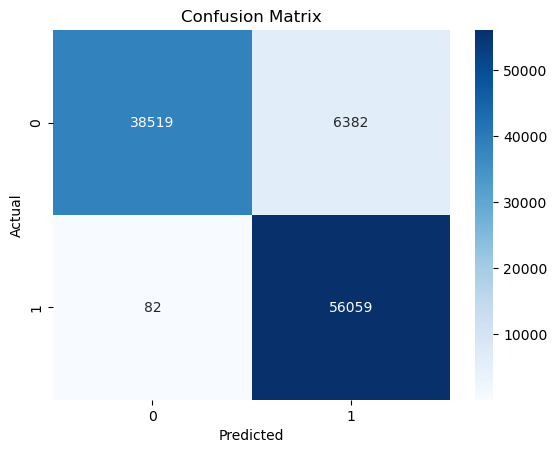

In [20]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Confusion Matrix Plot
plt.figure()
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [21]:
# Evaluation Metric 

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", round(accuracy_rf,2)*100)
print("Precision:", round(precision_rf,3)*100)
print("Recall   :", round(recall_rf,3)*100)
print("F1-Score :", round(f1_rf,3)*100)
print(classification_report(y_test, y_pred))

Accuracy : 94.0
Precision: 89.8
Recall   : 99.9
F1-Score : 94.5
              precision    recall  f1-score   support

         0.0       0.81      0.83      0.82     44901
         1.0       0.86      0.84      0.85     56141

    accuracy                           0.84    101042
   macro avg       0.84      0.84      0.84    101042
weighted avg       0.84      0.84      0.84    101042



* ### **Advanced Model - 2: XGBOOST**

In [22]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)
# Train
xgb.fit(x_train, y_train)

# Predict
y_pred_xgb = xgb.predict(x_test)

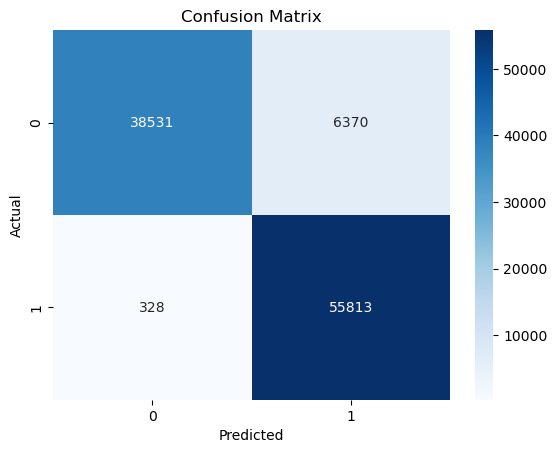

In [23]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Confusion Matrix Plot
plt.figure()
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [24]:
# Evaluation Metric 

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("Accuracy :", round(accuracy_xgb ,3)*100)
print("Precision:", round(precision_xgb ,3)*100)
print("Recall   :", round(recall_xgb  ,3)*100)
print("F1-Score :", round(f1_xgb ,3)*100)
print(classification_report(y_test, y_pred))

Accuracy : 93.4
Precision: 89.8
Recall   : 99.4
F1-Score : 94.3
              precision    recall  f1-score   support

         0.0       0.81      0.83      0.82     44901
         1.0       0.86      0.84      0.85     56141

    accuracy                           0.84    101042
   macro avg       0.84      0.84      0.84    101042
weighted avg       0.84      0.84      0.84    101042



## **Models Comparison**

In [27]:
# Create Model Comparison Table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_xgb],
    'Precision': [precision, precision_rf, precision_xgb],
    'Recall': [recall, recall_rf, recall_xgb],
    'F1 Score': [f1, f1_rf, f1_xgb]
})

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.838295,0.863329,0.842308,0.852689
1,Random Forest,0.936027,0.897792,0.998539,0.945489
2,XGBoost,0.933711,0.897560,0.994158,0.943393


In [35]:
# Select the model with the highest Recall score
best_model = comparison_df.loc[comparison_df['Recall'].idxmax()]

print("Best Model based on Recall:")
print(best_model)

Best Model based on Recall:
Model        Random Forest
Accuracy          0.936027
Precision         0.897792
Recall            0.998539
F1 Score          0.945489
Name: 1, dtype: object


In [36]:
# Model Ranking (by Recall)
comparison_df.sort_values(by='Recall', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.936027,0.897792,0.998539,0.945489
2,XGBoost,0.933711,0.897560,0.994158,0.943393
0,Logistic Regression,0.838295,0.863329,0.842308,0.852689


## **Final Model Selection & Conclusion**

After evaluating multiple models using Accuracy, Precision, Recall, and F1 Score, **Random Forest** emerged as the best-performing model for customer churn prediction.


### **Best Model Performance:**

- **Model:** Random Forest  
- **Accuracy:** 0.936  
- **Precision:** 0.898  
- **Recall:** 0.999  
- **F1 Score:** 0.945  

### **Interpretation:**

The Random Forest model achieved an exceptionally high recall score (≈ 0.999), making it highly effective at identifying customers who are likely to churn. This is particularly important in churn prediction, where failing to detect a churned customer (false negative) can lead to lost revenue and missed retention opportunities.

In addition to recall, the model also maintains strong performance across other metrics, with a high F1-score (≈ 0.945), indicating a good balance between precision and recall.

### **Important Consideration:**

While the model performs very well, the extremely high recall suggests that it may be slightly biased toward predicting churn, which could result in a higher number of false positives. This trade-off should be evaluated depending on business priorities — whether it is more important to minimize missed churn cases or avoid unnecessary retention efforts.

### **Final Decision:**

Based on the evaluation and the importance of maximizing recall in this problem, **Random Forest is selected as the final model for customer churn prediction**.